In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
sd=pd.read_csv("/content/CSV_WA_Fn-UseC_-Telco-Customer-Churn.csv")
sd

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure Group,Monthly spending category,Total Services,ServiceLevel
0,7590-VHVEG,Female,0,Yes,No,1,No,No,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,new,low,1,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,Yes,No,...,One year,No,Mailed check,56.95,1889.50,No,medium,medium,3,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,new,medium,3,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,old,medium,3,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,new,high,1,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,Yes,No,...,One year,Yes,Mailed check,84.80,1990.50,No,medium,high,7,High
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,No,Yes,...,One year,Yes,Credit card (automatic),103.20,7362.90,No,old,high,6,High
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,Yes,No,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,new,low,1,Low
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,No,No,...,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,new,high,2,Low


In [ ]:
sd.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'InternetService', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Tenure Group', 'Monthly spending category', 'Total Services',
       'ServiceLevel'],
      dtype='object')

In [48]:
sd.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
OnlineSecurity,0
OnlineBackup,0


In [49]:
sd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   gender                     7043 non-null   object 
 2   SeniorCitizen              7043 non-null   int64  
 3   Partner                    7043 non-null   object 
 4   Dependents                 7043 non-null   object 
 5   tenure                     7043 non-null   int64  
 6   PhoneService               7043 non-null   object 
 7   MultipleLines              7043 non-null   object 
 8   OnlineSecurity             7043 non-null   object 
 9   OnlineBackup               7043 non-null   object 
 10  DeviceProtection           7043 non-null   object 
 11  TechSupport                7043 non-null   object 
 12  StreamingTV                7043 non-null   object 
 13  StreamingMovies            7043 non-null   objec

In [50]:
sd.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Total Services
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,3.362914
std,0.368612,24.559481,30.090047,2266.794470,2.062031
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,1.000000
50%,0.000000,29.000000,70.350000,1394.550000,3.000000
75%,0.000000,55.000000,89.850000,3786.600000,5.000000
max,1.000000,72.000000,118.750000,8684.800000,8.000000


In [51]:
sd["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


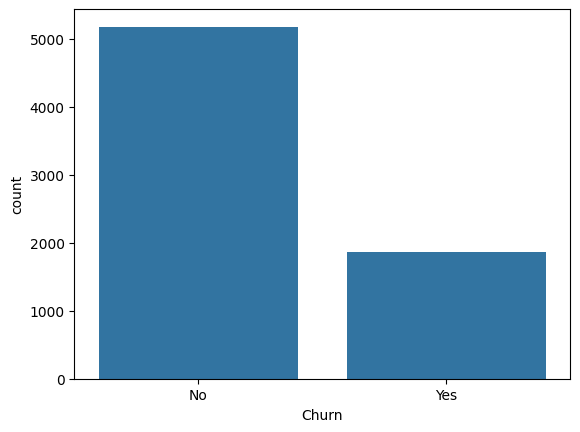

In [52]:
sns.countplot(x='Churn', data=sd)  #churn distibution
plt.show()
#Insight:
#Most customers are not churning, but around 26–27% customers have churned, which is a significant proportion and needs attention.

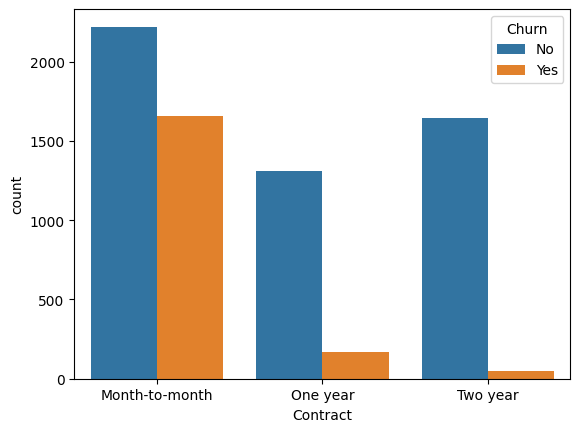

In [53]:
sns.countplot(x='Contract', hue='Churn', data=sd)  # categorical analysis contract wise churn showing
plt.show()
#Insight:
#Customers with month-to-month contracts have significantly higher churn compared to one-year and two-year contracts. Longer contract durations are associated with better customer retention.

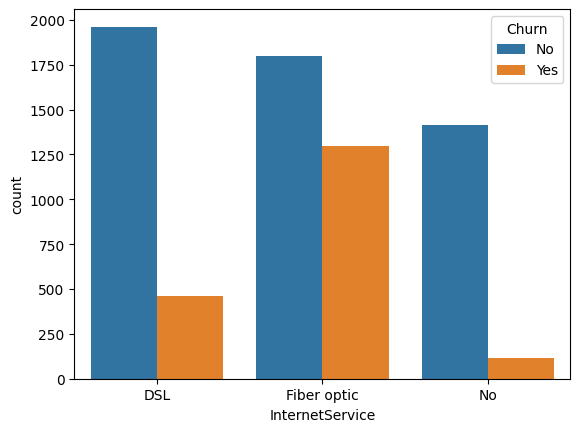

In [54]:
sns.countplot(x='InternetService', hue='Churn', data=sd) # categorical analysis internetservicet wise churn showing
plt.show()
#Insight:Customers using Fiber optic internet have higher churn compared to DSL and those with no internet service.

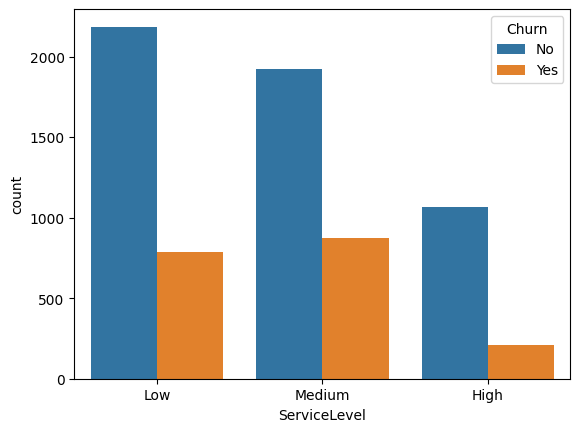

In [55]:
sns.countplot(x='ServiceLevel', hue='Churn', data=sd)   # categorical analysis servicelevel wise churn showing
plt.show()
#Insight:Customers with low service levels have significantly higher churn, while customers with high service levels show much lower churn.

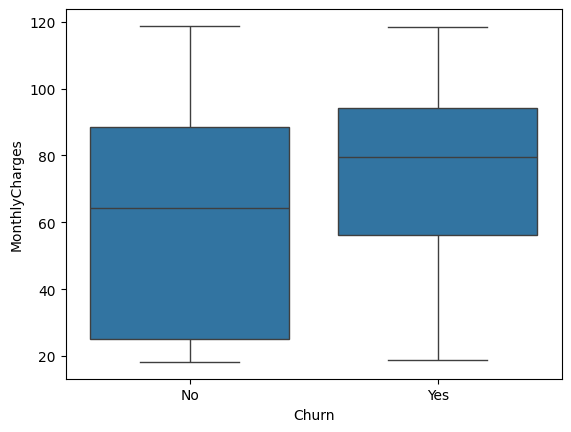

In [56]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=sd) #numerical analysis MonthlyCharges vs Churn
plt.show()
#Insight:The company should review pricing strategies or offer better value to high-paying customers to reduce churn.

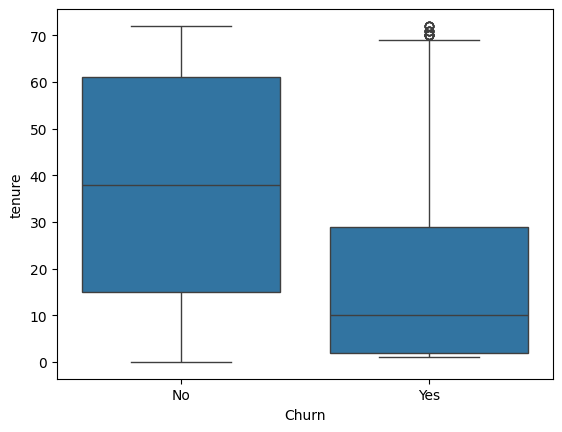

In [57]:
sns.boxplot(x='Churn', y='tenure', data=sd)
plt.show()
#Insight:The company should focus on improving the onboarding experience and engagement of new customers to reduce early churn.

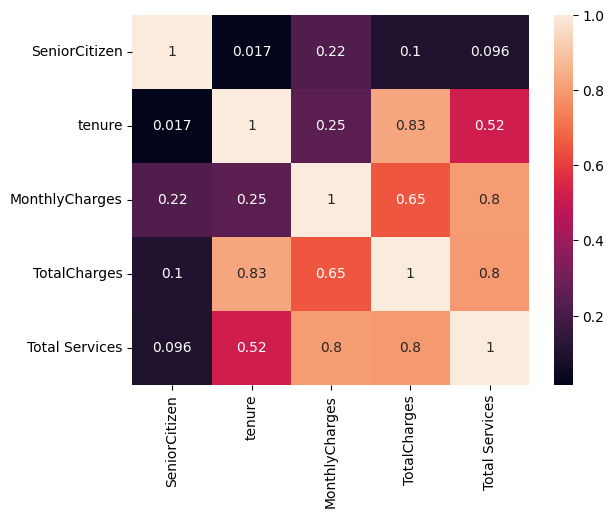

In [62]:
sns.heatmap(sd.corr(numeric_only=True), annot=True) #correlation
plt.show()
#Insight:Tenure and TotalCharges show strong positive correlation, indicating that longer customer duration leads to higher total spending.
#MonthlyCharges also positively correlates with TotalCharges, while other features show weaker relationships.

In [59]:
sd.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'InternetService', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Tenure Group', 'Monthly spending category', 'Total Services',
       'ServiceLevel'],
      dtype='object')

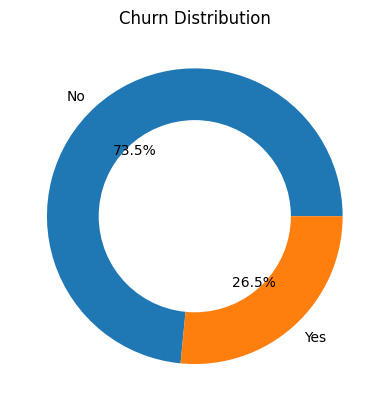

In [75]:
churn_counts = sd['Churn'].value_counts()

plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%')
centre_circle = plt.Circle((0,0),0.65,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Churn Distribution")
plt.show()
#Insight:Most customers stay, but a significant portion (26.5%) are leaving the service.